In [82]:
import pandas as pd
import numpy as np
from skimpy import clean_columns
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import savefig
from scipy import stats
from sklearn.metrics import r2_score


In [83]:
sites_2022 = pd.read_csv('Data/2022_sites.csv')
sites_2024 = pd.read_csv('Data/2024_sites.csv')

In [84]:
landscape_2022 = pd.read_csv('Landscape/2022_cdl_props.csv')
landscape_2022 = clean_columns(landscape_2022)
landscape_2024 = pd.read_csv('Landscape/2024_cdl_props.csv')
landscape_2024 = clean_columns(landscape_2024)

In [85]:
drainage_2022 = pd.read_csv('Soil/drainage_class_2022.csv')
drainage_2022 = clean_columns(drainage_2022)
drainage_2024 = pd.read_csv('Soil/drainage_class_2024.csv')
drainage_2024 = clean_columns(drainage_2024)

In [86]:
texture_2022 = pd.read_csv('Soil/soil_texture_2022.csv')
texture_2022 = clean_columns(texture_2022)
texture_2024 = pd.read_csv('Soil/soil_texture_2024.csv')
texture_2024 = clean_columns(texture_2024)

In [87]:
landscape_2024

,unnamed_0,farm,lat,long,corn,sorghum,soybeans,sunflower,sweet_corn,barley,...,semi_nat,semi_nat_prop,dev,dev_prop,other,other_prop,woodland,woodland_prop,forest_prop,total_nat_prop
0,0,Chaseholm,41.959261,-73.608753,194,0,0,0,0,0,...,1075,0.156690,141,0.020552,0,0.000000,2049,0.298658,0.294431,0.455347
1,1,Full Moon,41.753636,-74.122224,0,0,0,0,0,0,...,1312,0.191218,400,0.058298,0,0.000000,1751,0.255201,0.253160,0.446419
2,2,Boone,42.514032,-74.047356,75,0,14,0,0,0,...,1677,0.244427,572,0.083371,0,0.000000,1100,0.160328,0.142838,0.405921
3,3,Wilmar Farm,42.652490,-78.247704,64,10,20,0,0,0,...,716,0.104270,190,0.027669,3,0.000437,1353,0.197035,0.194705,0.301304
4,4,Hendricksons Grazing Acres,42.622045,-78.134195,229,0,0,0,0,0,...,685,0.099637,196,0.028509,0,0.000000,1844,0.268219,0.260510,0.368147
5,5,Tamberlane Farm,42.827978,-77.258460,0,0,1,0,0,0,...,595,0.086771,455,0.066354,2,0.000292,659,0.096104,0.085604,0.182875
6,6,Rugenstein,42.940091,-77.302841,588,1,20,0,0,1,...,1167,0.170135,281,0.040966,1,0.000146,754,0.109924,0.098407,0.281079
7,7,Charlie Reinshagen,42.378973,-74.666026,7,0,0,1,0,0,...,1204,0.175525,393,0.057293,0,0.000000,1847,0.269265,0.268390,0.444789
8,8,Maks Melvan,42.365790,-74.589692,0,0,0,0,0,0,...,1683,0.245280,266,0.038767,0,0.000000,1507,0.219630,0.218609,0.464909
9,9,LaurDom Cattle Co.,42.265233,-74.757086,0,0,0,0,0,0,...,1025,0.149482,193,0.028146,0,0.000000,2236,0.326089,0.324923,0.475571


In [88]:
dung_beetle = pd.read_csv('Data/2022_2024_species_data.csv')
dung_beetle = clean_columns(dung_beetle)
dung_beetle

,farm,date,year,week,feed_thru,feed_thru_type,fly_treat,fly_treat_type,pyrethroid,pyrethrin,...,ab_hy_large,ab_staph,richness_db,weather,windy,temperature,horn_flies_avg,face_flies_avg,stable_flies_avg,gps
0,Chaseholm,2024-05-15,2024,1,N,N,N,N,N,N,...,14.0,1.0,2.0,R,N,62.0,26.5,18.0,0.0,"41.959261, -73.608753"
1,Full Moon,2024-05-16,2024,1,N,N,N,N,N,N,...,12.0,1.0,2.0,R,Y,64.0,0.1,0.0,0.0,"41.753636, -74.122224"
2,Boone,2024-05-17,2024,1,Y,Clarifly,Y,diflubenzuron,N,N,...,23.0,1.0,5.0,S,N,75.0,0.0,0.0,0.0,"42.514032, -74.047356"
3,Wilmar Farm,2024-05-15,2024,1,Y,Altosid,Y,methoprene,N,N,...,14.0,10.0,5.0,C,N,60.0,0.0,3.5,0.0,"42.652490, -78.247704"
4,Hendricksons Grazing Acres,2024-05-15,2024,1,N,N,N,N,N,N,...,86.0,10.0,6.0,C,N,65.0,22.5,3.5,0.0,"42.622045, -78.134195"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,Kuipers,2022-09-29,2022,22,Y,Rabon,N,N,N,N,...,0.0,0.0,2.0,C,NaN,48.0,2.0,0.0,NaN,"42.652410995744475, -78.24775957397635"
406,Honeyhill,2022-09-29,2022,22,N,N,N,N,N,N,...,0.0,0.0,0.0,PC,N,48.0,0.0,0.0,NaN,"42.7876199,-77.6811557"
407,Rugenstein,2022-09-29,2022,22,Y,Clarifly,Y,permethrin,N,Y,...,0.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,"43.06299375705573, -77.30374234638641"
408,Eisele,2022-09-29,2022,22,N,N,N,N,N,N,...,0.0,0.0,0.0,C,NaN,50.0,2.6,4.0,NaN,"42.158070, -74.802461"


In [89]:
dung_beetle_diversity = pd.read_csv('Data/dung_beetle_diversity.csv')
dung_beetle_diversity = clean_columns(dung_beetle_diversity)
dung_beetle_diversity

,farm,date,year,calamosternus_granarius,colobopterus_erraticus,aphodius_fimetarius,otophorus,oscarinus_rusicola,alloblackburneus_rubeolus,acrossus_rubripennis,...,unnamed_21,onthopagus_abundance,aphodius_abundance,total_abundance,q_0_richness,q_1_shannon,q_2_simpson,native_species_abundance,native_species_richness,native_species_proportion
0,Chaseholm,2024-05-15,2024,0,29,0,6,0,0,0,...,NaN,0,35,35,2,1.581137,1.396807,0,0,0.000000
1,Full Moon,2024-05-16,2024,0,0,0,1,3,0,0,...,NaN,0,4,4,2,1.754765,1.600000,3,1,0.250000
2,Golden Acres,2024-05-17,2024,3,57,0,2,3,2,0,...,NaN,0,67,67,5,1.868838,1.370687,5,2,0.029851
3,Wilmar Farm,2024-05-15,2024,99,27,2,0,0,0,0,...,NaN,3,129,132,5,2.068540,1.652504,0,0,0.000000
4,Hendricksons Grazing Acres,2024-05-15,2024,4,80,0,3,1,0,0,...,NaN,13,92,105,6,2.364808,1.667675,1,1,0.010870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,Kuipers,2022-09-29,2022,0,1,0,0,0,0,0,...,NaN,2,1,3,2,1.889882,1.800000,0,0,0.000000
381,Honeyhill,2022-09-29,2022,0,0,0,0,0,0,0,...,NaN,0,0,0,0,NaN,NaN,0,0,NaN
382,Rugenstein,2022-09-29,2022,0,0,0,0,0,0,0,...,NaN,0,2,2,2,2.000000,2.000000,2,2,1.000000
383,Eisele,2022-09-29,2022,0,0,0,0,0,0,0,...,NaN,0,0,0,0,NaN,NaN,0,0,NaN


In [90]:
dung_beetle_22 = dung_beetle.loc[dung_beetle['year'] == 2022]
dung_beetle_22

,farm,date,year,week,feed_thru,feed_thru_type,fly_treat,fly_treat_type,pyrethroid,pyrethrin,...,ab_hy_large,ab_staph,richness_db,weather,windy,temperature,horn_flies_avg,face_flies_avg,stable_flies_avg,gps
190,Chaseholm,2024-05-03,2022,1,N,N,N,N,N,N,...,6.0,0.0,1.0,S,NaN,55.0,NaN,NaN,NaN,"41.98788599305552, -73.61780360369838"
191,Wallbridge,NaN,2022,1,Y,Clarifly,Y,permethrin,N,Y,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"41.774997612249, -73.6515655461982"
192,JohnK,NaN,2022,1,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"42.40061728166515, -73.99420583068292"
193,Boone,NaN,2022,1,Y,Clarifly,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"42.54463393478293, -74.03369647630593"
194,Turner,2022-05-04,2022,1,N,N,N,N,N,N,...,8.0,3.0,1.0,C,NaN,57.0,0.0,32.0,NaN,"42.22686594127726, -76.99705251164634"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,Kuipers,2022-09-29,2022,22,Y,Rabon,N,N,N,N,...,0.0,0.0,2.0,C,NaN,48.0,2.0,0.0,NaN,"42.652410995744475, -78.24775957397635"
406,Honeyhill,2022-09-29,2022,22,N,N,N,N,N,N,...,0.0,0.0,0.0,PC,N,48.0,0.0,0.0,NaN,"42.7876199,-77.6811557"
407,Rugenstein,2022-09-29,2022,22,Y,Clarifly,Y,permethrin,N,Y,...,0.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,"43.06299375705573, -77.30374234638641"
408,Eisele,2022-09-29,2022,22,N,N,N,N,N,N,...,0.0,0.0,0.0,C,NaN,50.0,2.6,4.0,NaN,"42.158070, -74.802461"


In [91]:
dung_beetle_diversity_22 = dung_beetle_diversity.loc[dung_beetle_diversity['year'] == 2022]
dung_beetle_diversity_22

,farm,date,year,calamosternus_granarius,colobopterus_erraticus,aphodius_fimetarius,otophorus,oscarinus_rusicola,alloblackburneus_rubeolus,acrossus_rubripennis,...,unnamed_21,onthopagus_abundance,aphodius_abundance,total_abundance,q_0_richness,q_1_shannon,q_2_simpson,native_species_abundance,native_species_richness,native_species_proportion
173,Chaseholm,2022-05-03,2022,0,20,0,0,0,0,0,...,NaN,0,20,20,1,1.000000,1.000000,0,0,0.000000
174,Turner,2022-05-04,2022,0,0,0,0,0,0,2,...,NaN,0,2,2,1,1.000000,1.000000,2,1,0.500000
175,Kuipers,2022-05-04,2022,1,0,0,0,1,0,0,...,NaN,0,3,3,3,3.000000,3.000000,2,2,0.666667
176,Rugenstein,2022-05-06,2022,13,14,0,0,12,0,0,...,NaN,1,39,40,4,3.274381,3.137255,12,1,0.025641
177,Eisele,2022-05-05,2022,0,6,0,0,0,0,0,...,NaN,0,6,6,1,1.000000,1.000000,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,Kuipers,2022-09-29,2022,0,1,0,0,0,0,0,...,NaN,2,1,3,2,1.889882,1.800000,0,0,0.000000
381,Honeyhill,2022-09-29,2022,0,0,0,0,0,0,0,...,NaN,0,0,0,0,NaN,NaN,0,0,NaN
382,Rugenstein,2022-09-29,2022,0,0,0,0,0,0,0,...,NaN,0,2,2,2,2.000000,2.000000,2,2,1.000000
383,Eisele,2022-09-29,2022,0,0,0,0,0,0,0,...,NaN,0,0,0,0,NaN,NaN,0,0,NaN


In [92]:
dung_beetle_24 = dung_beetle.loc[dung_beetle['year'] == 2024]
dung_beetle_24

,farm,date,year,week,feed_thru,feed_thru_type,fly_treat,fly_treat_type,pyrethroid,pyrethrin,...,ab_hy_large,ab_staph,richness_db,weather,windy,temperature,horn_flies_avg,face_flies_avg,stable_flies_avg,gps
0,Chaseholm,2024-05-15,2024,1,N,N,N,N,N,N,...,14.0,1.0,2.0,R,N,62.0,26.5,18.0,0.0,"41.959261, -73.608753"
1,Full Moon,2024-05-16,2024,1,N,N,N,N,N,N,...,12.0,1.0,2.0,R,Y,64.0,0.1,0.0,0.0,"41.753636, -74.122224"
2,Boone,2024-05-17,2024,1,Y,Clarifly,Y,diflubenzuron,N,N,...,23.0,1.0,5.0,S,N,75.0,0.0,0.0,0.0,"42.514032, -74.047356"
3,Wilmar Farm,2024-05-15,2024,1,Y,Altosid,Y,methoprene,N,N,...,14.0,10.0,5.0,C,N,60.0,0.0,3.5,0.0,"42.652490, -78.247704"
4,Hendricksons Grazing Acres,2024-05-15,2024,1,N,N,N,N,N,N,...,86.0,10.0,6.0,C,N,65.0,22.5,3.5,0.0,"42.622045, -78.134195"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,Essex Farm,2024-09-15,2024,10,N,N,Y,pyrethrins,N,Y,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"44.309224, -73.369184"
186,Daona,2024-09-15,2024,10,Y,Clarifly,Y,diflubenzuron,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"43.87937158694747, -73.31594295713514"
187,KZ,2024-09-15,2024,10,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"44.21408785253618, -73.44422118959798"
188,J+R Pierce,2024-09-15,2024,10,N,N,Y,permethrin,Y,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"44.78597240570679, -73.52093274538599"


In [93]:
dung_beetle_diversity_24 = dung_beetle_diversity.loc[dung_beetle_diversity['year'] == 2024]
dung_beetle_diversity_24

,farm,date,year,calamosternus_granarius,colobopterus_erraticus,aphodius_fimetarius,otophorus,oscarinus_rusicola,alloblackburneus_rubeolus,acrossus_rubripennis,...,unnamed_21,onthopagus_abundance,aphodius_abundance,total_abundance,q_0_richness,q_1_shannon,q_2_simpson,native_species_abundance,native_species_richness,native_species_proportion
0,Chaseholm,2024-05-15,2024,0,29,0,6,0,0,0,...,NaN,0,35,35,2,1.581137,1.396807,0,0,0.000000
1,Full Moon,2024-05-16,2024,0,0,0,1,3,0,0,...,NaN,0,4,4,2,1.754765,1.600000,3,1,0.250000
2,Golden Acres,2024-05-17,2024,3,57,0,2,3,2,0,...,NaN,0,67,67,5,1.868838,1.370687,5,2,0.029851
3,Wilmar Farm,2024-05-15,2024,99,27,2,0,0,0,0,...,NaN,3,129,132,5,2.068540,1.652504,0,0,0.000000
4,Hendricksons Grazing Acres,2024-05-15,2024,4,80,0,3,1,0,0,...,NaN,13,92,105,6,2.364808,1.667675,1,1,0.010870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,Maks Melvan,2024-09-19,2024,0,0,1,0,0,0,0,...,NaN,0,1,1,1,1.000000,1.000000,0,0,0.000000
169,LaurDom Cattle Co.,2024-09-19,2024,0,0,1,1,0,0,0,...,NaN,1,2,3,3,3.000000,3.000000,1,1,0.500000
170,Stony Creek Farm,2024-09-19,2024,0,0,2,3,1,0,0,...,NaN,1,7,8,5,4.455660,4.000000,3,3,0.428571
171,Porco,2024-09-15,2024,0,0,0,0,0,0,0,...,NaN,0,0,0,0,NaN,NaN,0,0,NaN


In [94]:
dung_beetle_22 = dung_beetle_22.merge(landscape_2022, on='farm')
dung_beetle_22

,farm,date,year,week,feed_thru,feed_thru_type,fly_treat,fly_treat_type,pyrethroid,pyrethrin,...,semi_nat,semi_nat_prop,dev,dev_prop,other_y,other_prop,woodland,woodland_prop,forest_prop,total_nat_prop
0,Chaseholm,2024-05-03,2022,1,N,N,N,N,N,N,...,732,0.231912,181,0.057344,0.0,0.0,1518,0.480932,0.457488,0.713161
1,Wallbridge,NaN,2022,1,Y,Clarifly,Y,permethrin,N,Y,...,752,0.238494,166,0.052646,0.0,0.0,2001,0.634609,0.579743,0.874054
2,JohnK,NaN,2022,1,N,N,N,N,N,N,...,270,0.084815,203,0.063768,0.0,0.0,2623,0.823960,0.757993,0.912544
3,Boone,NaN,2022,1,Y,Clarifly,N,N,N,N,...,186,0.058371,89,0.027930,0.0,0.0,2672,0.838535,0.818764,0.908517
4,Turner,2022-05-04,2022,1,N,N,N,N,N,N,...,514,0.162441,217,0.068579,0.0,0.0,2334,0.737620,0.734460,0.900377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,Kuipers,2022-09-29,2022,22,Y,Rabon,N,N,N,N,...,212,0.066533,201,0.063081,0.0,0.0,1136,0.356515,0.332036,0.423989
216,Honeyhill,2022-09-29,2022,22,N,N,N,N,N,N,...,822,0.257027,316,0.098808,0.0,0.0,968,0.302679,0.287358,0.560019
217,Rugenstein,2022-09-29,2022,22,Y,Clarifly,Y,permethrin,N,Y,...,495,0.154073,1037,0.322776,0.0,0.0,1415,0.440431,0.319974,0.594816
218,Eisele,2022-09-29,2022,22,N,N,N,N,N,N,...,415,0.131273,181,0.057254,0.0,0.0,2339,0.739872,0.731332,0.871778


In [95]:
dung_beetle_diversity_22 = dung_beetle_diversity_22.merge(landscape_2022, on='farm')
dung_beetle_diversity_22 = dung_beetle_diversity_22.merge(drainage_2022, on='farm')
dung_beetle_diversity_22 = dung_beetle_diversity_22.merge(texture_2022, on='farm')


dung_beetle_diversity_22['julian_day'] = pd.to_datetime(dung_beetle_diversity_22['date']).dt.dayofyear

# Spring - March 20 (79-171)
# Summer - June 21 (172-265)
# Fall - September 22 (266-355)
# Winter - December 21 (355-365, 1-78)

conditions = [
    ((dung_beetle_diversity_22['julian_day'] >= 79) & (dung_beetle_diversity_22['julian_day'] <= 171)),
    ((dung_beetle_diversity_22['julian_day'] >= 172) & (dung_beetle_diversity_22['julian_day'] <= 265)),
    ((dung_beetle_diversity_22['julian_day'] >= 266) & (dung_beetle_diversity_22['julian_day'] <= 355)),
    ((dung_beetle_diversity_22['julian_day'] >= 355) | dung_beetle_diversity_22['julian_day'] <= 78)
]

choices = ['spring', 'summer', 'fall', 'winter']

dung_beetle_diversity_22['season'] = np.select(conditions, choices)


In [96]:
dung_beetle_diversity_24 = dung_beetle_diversity_24.merge(landscape_2024, on='farm')
dung_beetle_diversity_24 = dung_beetle_diversity_24.merge(drainage_2024, on='farm')
dung_beetle_diversity_24 = dung_beetle_diversity_24.merge(texture_2024, on='farm')


dung_beetle_diversity_24['julian_day'] = pd.to_datetime(dung_beetle_diversity_24['date']).dt.dayofyear

# Spring - March 20 (80-172)
# Summer - June 21 (173-266)
# Fall - September 22 (267-355)
# Winter - December 21 (356-366, 1-79)

conditions = [
    ((dung_beetle_diversity_24['julian_day'] >= 80) & (dung_beetle_diversity_24['julian_day'] <= 172)),
    ((dung_beetle_diversity_24['julian_day'] >= 173) & (dung_beetle_diversity_24['julian_day'] <= 266)),
    ((dung_beetle_diversity_24['julian_day'] >= 267) & (dung_beetle_diversity_24['julian_day'] <= 355)),
    ((dung_beetle_diversity_24['julian_day'] >= 356) | dung_beetle_diversity_24['julian_day'] <= 79)
]

choices = ['spring', 'summer', 'fall', 'winter']

dung_beetle_diversity_24['season'] = np.select(conditions, choices)

dung_beetle_diversity_24

,farm,date,year,calamosternus_granarius,colobopterus_erraticus,aphodius_fimetarius,otophorus,oscarinus_rusicola,alloblackburneus_rubeolus,acrossus_rubripennis,...,other,other_prop,woodland,woodland_prop,forest_prop,total_nat_prop,drainage,soil_texture,julian_day,season
0,Chaseholm,2024-05-15,2024,0,29,0,6,0,0,0,...,0,0.000000,2049,0.298658,0.294431,0.455347,8,5,136,spring
1,Full Moon,2024-05-16,2024,0,0,0,1,3,0,0,...,0,0.000000,1751,0.255201,0.253160,0.446419,5,9,137,spring
2,Wilmar Farm,2024-05-15,2024,99,27,2,0,0,0,0,...,3,0.000437,1353,0.197035,0.194705,0.301304,2,5,136,spring
3,Hendricksons Grazing Acres,2024-05-15,2024,4,80,0,3,1,0,0,...,0,0.000000,1844,0.268219,0.260510,0.368147,2,5,136,spring
4,Tamberlane Farm,2024-05-15,2024,9,14,0,4,2,0,0,...,2,0.000292,659,0.096104,0.085604,0.182875,2,4,136,spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,Maks Melvan,2024-09-19,2024,0,0,1,0,0,0,0,...,0,0.000000,1507,0.219630,0.218609,0.464909,2,5,263,summer
159,LaurDom Cattle Co.,2024-09-19,2024,0,0,1,1,0,0,0,...,0,0.000000,2236,0.326089,0.324923,0.475571,8,5,263,summer
160,Stony Creek Farm,2024-09-19,2024,0,0,2,3,1,0,0,...,0,0.000000,2343,0.341730,0.341292,0.480726,8,5,263,summer
161,Porco,2024-09-15,2024,0,0,0,0,0,0,0,...,0,0.000000,207,0.030146,0.026068,0.346172,5,5,259,summer


In [97]:
diversity_landscape = pd.concat([dung_beetle_diversity_22, dung_beetle_diversity_24])
diversity_landscape = clean_columns(diversity_landscape)
diversity_landscape

,farm,date,year,calamosternus_granarius,colobopterus_erraticus,aphodius_fimetarius,otophorus,oscarinus_rusicola,alloblackburneus_rubeolus,acrossus_rubripennis,...,sod_grass_seed,other_tree_crops,aquaculture,triticale,carrots,broccoli,greens,squash,dbl_crop_triticale_corn,pumpkins
0,Chaseholm,2022-05-03,2022,0,20,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turner,2022-05-04,2022,0,0,0,0,0,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Kuipers,2022-05-04,2022,1,0,0,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Rugenstein,2022-05-06,2022,13,14,0,0,12,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Eisele,2022-05-05,2022,0,6,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,Maks Melvan,2024-09-19,2024,0,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
159,LaurDom Cattle Co.,2024-09-19,2024,0,0,1,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160,Stony Creek Farm,2024-09-19,2024,0,0,2,3,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
161,Porco,2024-09-15,2024,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,105.0,0.0


In [98]:
diversity_landscape.to_csv('Data/diversity_landscape.csv')

<Axes: >

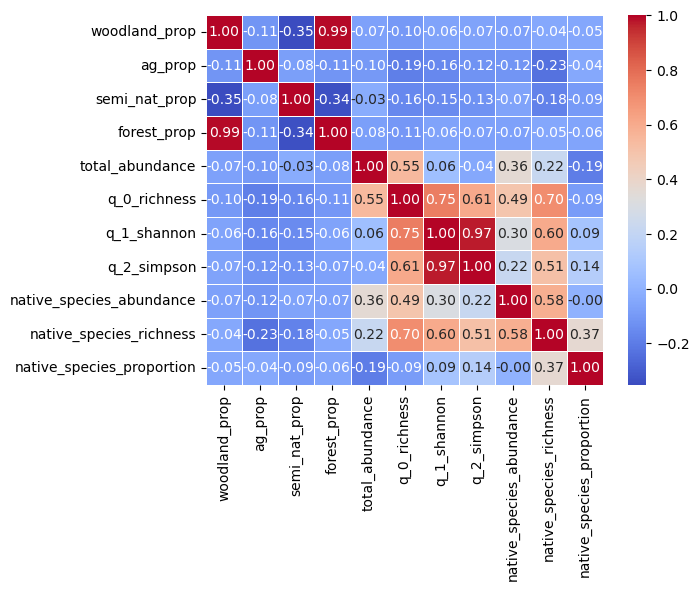

In [85]:
selected_columns = ['woodland_prop', 'ag_prop', 'semi_nat_prop', 'forest_prop', 'total_abundance', 'q_0_richness', 'q_1_shannon',
                    'q_2_simpson', 'native_species_abundance', 'native_species_richness',
                    'native_species_proportion']

corr_matrix = diversity_landscape[selected_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)


<Axes: >

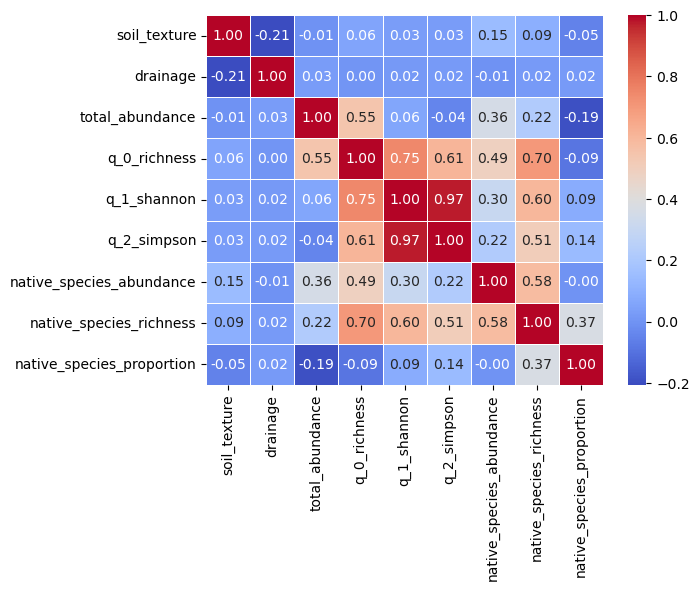

In [99]:
selected_columns = ['soil_texture', 'drainage', 'total_abundance', 'q_0_richness', 'q_1_shannon',
                    'q_2_simpson', 'native_species_abundance', 'native_species_richness',
                    'native_species_proportion']

corr_matrix = diversity_landscape[selected_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
